# 01 - PTB-XL exploratory data analysis

PTB-XL is a public collection of 21,799 clinical twelve-lead ECGs from 18,869 patients, recorded in
Germany between 1984 and 2001 and annotated by cardiologists with SCP-ECG statements. This notebook
describes the dataset itself: what is recorded, what is missing or wrong, how diagnoses relate to age
and sex, and what the waveforms look like.

Everything is computed from the raw PTB-XL 1.0.3 release (`data/raw/ptb-xl/1.0.3/`). The analysis code
lives in `ecg_experiment/eda/` as plain Python; this notebook calls it and explains the results.

**How to read it.** Each section starts with the question, shows the evidence and ends with a short
*Finding*. The conclusions are collected at the end.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ecg_experiment.eda.ptbxl import (
    SUPERCLASSES,
    diagnostic_classes,
    implausible_rows,
    load_metadata,
    load_statements,
    read_signal,
    superclass_flags,
    superclasses,
)
from ecg_experiment.eda.ptbxl_signals import (
    annotation_agreement,
    lead_features,
    low_rate_consistency,
    ptbxl_summary,
)
from ecg_experiment.eda.signals import LEADS, plot_ecg, problem_counts
from ecg_experiment.eda.stats import age_band, association_test, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

meta = load_metadata()
statements = load_statements()
classes = diagnostic_classes(statements)
meta = meta.join(superclass_flags(meta, classes))
meta["classes"] = meta["scp_codes"].apply(superclasses, classes=classes)
meta["male"] = meta["sex"].eq(0)
meta["sex_name"] = np.where(meta["male"], "male", "female")
meta["age_band"] = age_band(meta["age_capped"])

## 1. The data at a glance

Basic shape: recordings, patients, and the ten stratified folds the release defines.

In [3]:
overview = pd.Series({
    "recordings": len(meta),
    "patients": meta["patient_id"].nunique(),
    "metadata columns": meta.shape[1],
    "first recording": meta["recording_date"].min().date(),
    "last recording": meta["recording_date"].max().date(),
})
display(overview.to_frame("value"))
display(meta.groupby("strat_fold").agg(records=("patient_id", "size"),
                                       patients=("patient_id", "nunique"),
                                       human_validated=("validated_by_human", "mean")).T.round(2))
per_patient = meta.groupby("patient_id").size()
display(per_patient.value_counts().sort_index().to_frame("patients with this many ECGs").T)

,value
recordings,21799
patients,18869
metadata columns,38
first recording,1984-11-09
last recording,2001-06-11


strat_fold,1,2,3,4,5,6,7,8,9,10
records,2175.00,2181.00,2192.00,2174.00,2174.00,2173.00,2176.00,2173.00,2183.0,2198.0
patients,1878.00,1849.00,1887.00,1883.00,1890.00,1884.00,1871.00,1881.00,1942.0,1904.0
human_validated,0.67,0.66,0.67,0.68,0.68,0.64,0.68,0.68,1.0,1.0


,1,2,3,4,5,6,7,8,9,10
patients with this many ECGs,16758,1590,350,99,43,16,5,4,3,1


**Finding.** 21,799 ten-second recordings from 18,869 patients. 2,111 patients have more than one ECG
(up to 10), so records are not independent: any statistic or split should account for patients. The
ten folds are balanced in size, and each patient sits in exactly one fold. Folds 9 and 10 were fully
reviewed by a human cardiologist, against about two thirds of the other folds.

## 2. Missing values

Missing values limit which metadata can be used, and in PTB-XL several columns use "missing" to mean
"not annotated" rather than "unknown".

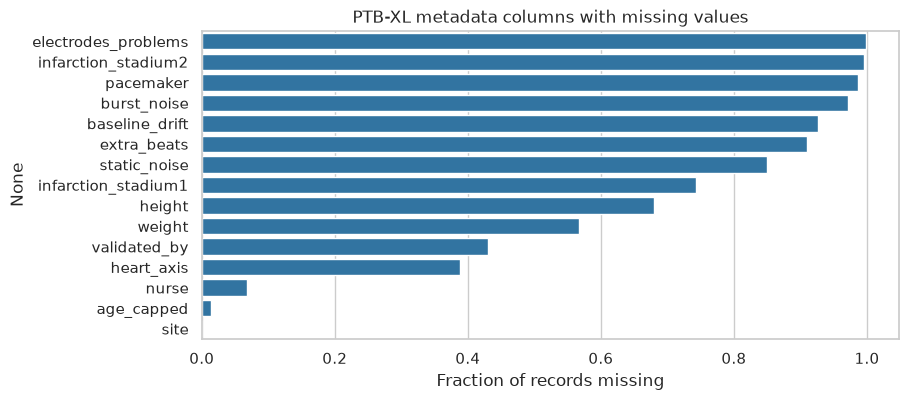

,missing fraction
electrodes_problems,0.999
infarction_stadium2,0.995
pacemaker,0.987
burst_noise,0.972
baseline_drift,0.927
extra_beats,0.911
static_noise,0.850
infarction_stadium1,0.743
height,0.680
weight,0.568


In [4]:
missing = meta.drop(columns=["scp_codes"]).isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].drop("age_band", errors="ignore")
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=missing.to_numpy(), y=missing.index, ax=ax, color="tab:blue")
ax.set(xlabel="Fraction of records missing", title="PTB-XL metadata columns with missing values")
plt.show()
display(missing.round(3).to_frame("missing fraction"))

In [5]:
columns = ["height", "weight", "heart_axis", "nurse"]
by_diagnosis = meta.groupby("abnormal")[columns].apply(lambda values: values.isna().mean())
display(by_diagnosis.rename(index={False: "no abnormal superclass", True: "abnormal superclass"}).round(3))

,height,weight,heart_axis,nurse
abnormal,,,,
no abnormal superclass,0.672,0.464,0.469,0.059
abnormal superclass,0.687,0.647,0.326,0.074


**Finding.** The core fields (patient, fold, SCP codes, age, sex, device) are complete. The gaps are
elsewhere:

- The noise columns (`baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`) are empty
  in 85-99% of rows. Empty means "the annotator noted nothing", not "unknown". Section 7 checks these
  annotations against the measured signals.
- Height (68% missing) and weight (57% missing) are sparse, and **they are not missing at random**.
  Height is missing equally often with and without an abnormal finding (69% vs 67%), but weight is
  missing much more often for abnormal records (65% vs 46%). The recorded weights are therefore a
  biased subset. The heart axis goes the other way: it is recorded more often when the ECG is abnormal
  (missing in 33% vs 47%), presumably because cardiologists note it when it matters.
- Age is always present, but it hides a placeholder, checked next.

## 3. Implausible and placeholder values

Values that are present but cannot be right. Children legitimately have small heights and weights, so
the size rules only apply to adults.

In [6]:
flags = implausible_rows(meta)
display(flags.sum().to_frame("records"))
suspicious = meta.loc[flags.drop(columns="age 300 (placeholder for > 89)").any(axis=1),
                      ["age", "sex_name", "height", "weight"]]
display(suspicious.sort_values("height"))
children = meta[(meta["age_capped"] < 18) & meta["height"].notna()]
display(children[["age", "height", "weight"]].describe().round(1))

,records
age 300 (placeholder for > 89),293
adult height < 120 cm,12
adult weight < 30 kg,3
weight > 180 kg,5
BMI < 12 or > 70,5


,age,sex_name,height,weight
ecg_id,,,,
9384,79.0,female,6.0,NaN
15207,86.0,female,6.0,NaN
9317,64.0,male,6.0,NaN
6266,60.0,female,66.0,NaN
6430,46.0,female,67.0,NaN
6481,76.0,male,80.0,NaN
15351,84.0,female,90.0,NaN
15514,84.0,female,90.0,NaN
18173,64.0,male,93.0,NaN


,age,height,weight
count,45.0,45.0,42.0
mean,12.4,152.2,48.7
std,4.4,26.2,22.6
min,2.0,85.0,12.0
25%,10.0,144.0,35.2
50%,13.0,160.0,49.5
75%,16.0,170.0,60.0
max,17.0,185.0,120.0


**Finding.** Few values are wrong, but they are clearly wrong:

- **293 records have age 300.** This is PTB-XL's privacy placeholder for patients older than 89. It
  must be treated as "over 89", never as a number. This notebook uses `age_capped`, where it is NaN.
- **12 adults are shorter than 120 cm**, including three at 6 cm, and **3 adults weigh under 30 kg**
  (two at 5 kg). These are data-entry errors, most likely a missing digit or a shifted field.
- The small heights and weights of children (ages 2-17) are consistent with their age and are real,
  with one exception: a 4-year-old recorded at 140 cm and 15 kg.
- 5 weights above 180 kg are possible but extreme; four have no height, so their BMI cannot be checked.

Height and weight should be cleaned with these rules before being used.

## 4. Who is in the dataset

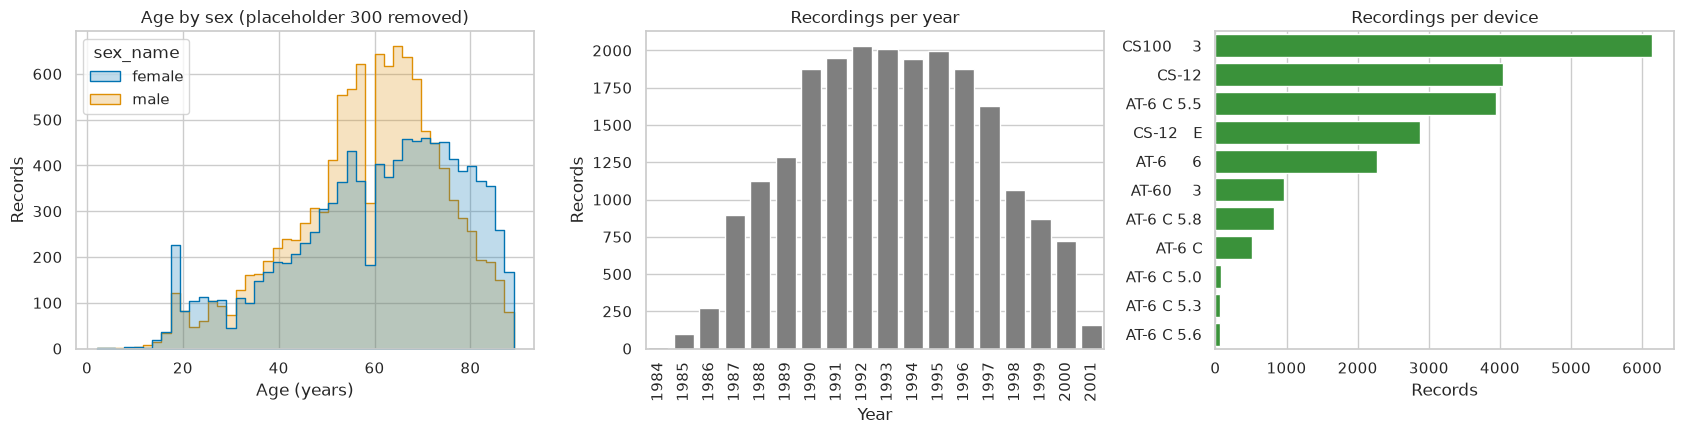

,count,mean,std,min,25%,50%,75%,max
sex_name,,,,,,,,
female,10220.0,60.4,18.0,3.0,49.0,63.0,75.0,89.0
male,11286.0,58.8,15.5,2.0,50.0,60.0,69.0,89.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(meta, x="age_capped", hue="sex_name", bins=45, element="step", ax=axes[0])
axes[0].set(title="Age by sex (placeholder 300 removed)", xlabel="Age (years)", ylabel="Records")
sns.countplot(x=meta["recording_date"].dt.year, ax=axes[1], color="tab:gray")
axes[1].set(title="Recordings per year", xlabel="Year", ylabel="Records")
axes[1].tick_params(axis="x", rotation=90)
sns.countplot(meta, y="device", order=meta["device"].value_counts().index, ax=axes[2], color="tab:green")
axes[2].set(title="Recordings per device", xlabel="Records", ylabel="")
plt.tight_layout()
plt.show()
display(meta.groupby("sex_name")["age_capped"].describe().round(1))

**Finding.** The population is older (median age 61) and slightly male (52%). Women are older than men
in this cohort (a visibly later age peak). Recordings come from 11 device models, with `CS100 3` the
largest single group. Section 8 shows that devices differ in their signals.

## 5. Diagnostic statements

Each record lists SCP-ECG statements with a likelihood (0-100). Statements are *diagnostic* (grouped
into five superclasses: NORM normal, MI myocardial infarction, STTC ST/T change, CD conduction
disturbance, HYP hypertrophy), *form* or *rhythm*. Below, a superclass counts as present when any of its
statements is listed, the convention of the PTB-XL benchmark.

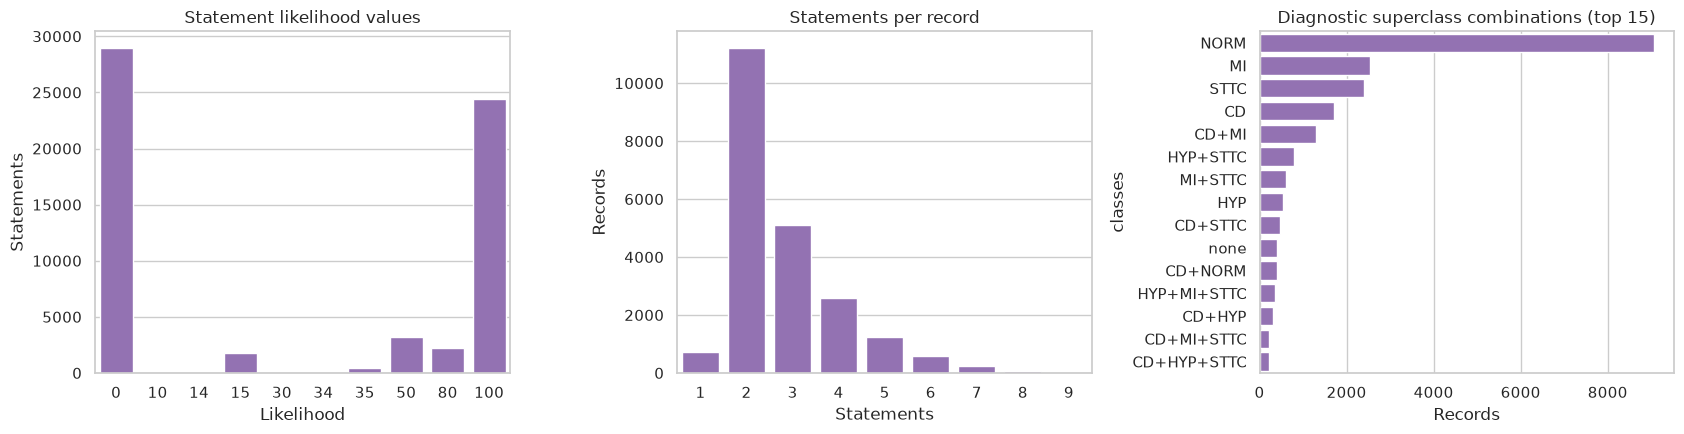

,share of records
NORM,0.436
MI,0.251
STTC,0.240
CD,0.225
HYP,0.122
abnormal,0.565


Records with NORM and an abnormal superclass at the same time: 445
Records with no diagnostic statement at all: 411


In [8]:
likelihoods = pd.Series([value for codes in meta["scp_codes"] for value in codes.values()])
codes_per_record = meta["scp_codes"].apply(len)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.countplot(x=likelihoods.astype(int), ax=axes[0], color="tab:purple")
axes[0].set(title="Statement likelihood values", xlabel="Likelihood", ylabel="Statements")
sns.countplot(x=codes_per_record, ax=axes[1], color="tab:purple")
axes[1].set(title="Statements per record", xlabel="Statements", ylabel="Records")
top = meta["classes"].value_counts().head(15)
sns.barplot(x=top.to_numpy(), y=top.index, ax=axes[2], color="tab:purple")
axes[2].set(title="Diagnostic superclass combinations (top 15)", xlabel="Records")
plt.tight_layout()
plt.show()
display(meta[[*SUPERCLASSES, "abnormal"]].mean().round(3).to_frame("share of records"))
conflict = meta["NORM"] & meta["abnormal"]
print(f"Records with NORM and an abnormal superclass at the same time: {conflict.sum()}")
print(f"Records with no diagnostic statement at all: {(meta['classes'] == 'none').sum()}")

**Finding.** Most likelihoods are 100 or 0; in PTB-XL, 0 means "likelihood not specified", not
"absent". Records carry a median of 2 statements, and superclasses overlap heavily (MI with CD, HYP
with STTC). 44% of records are NORM and 57% have at least one abnormal superclass. The two overlap
slightly: some records are NORM and also carry an abnormal statement, which is a genuine annotation
conflict. 411 records have no diagnostic statement at all, only rhythm or form codes (pacemaker,
atrial fibrillation, flutter...).

## 6. Diagnoses, age and sex

How strongly does having a heart problem depend on age and sex? We show the share of records with
each superclass per age band (with 95% intervals), test the association, and fit a logistic
regression per superclass with age (per 10 years) and sex together.

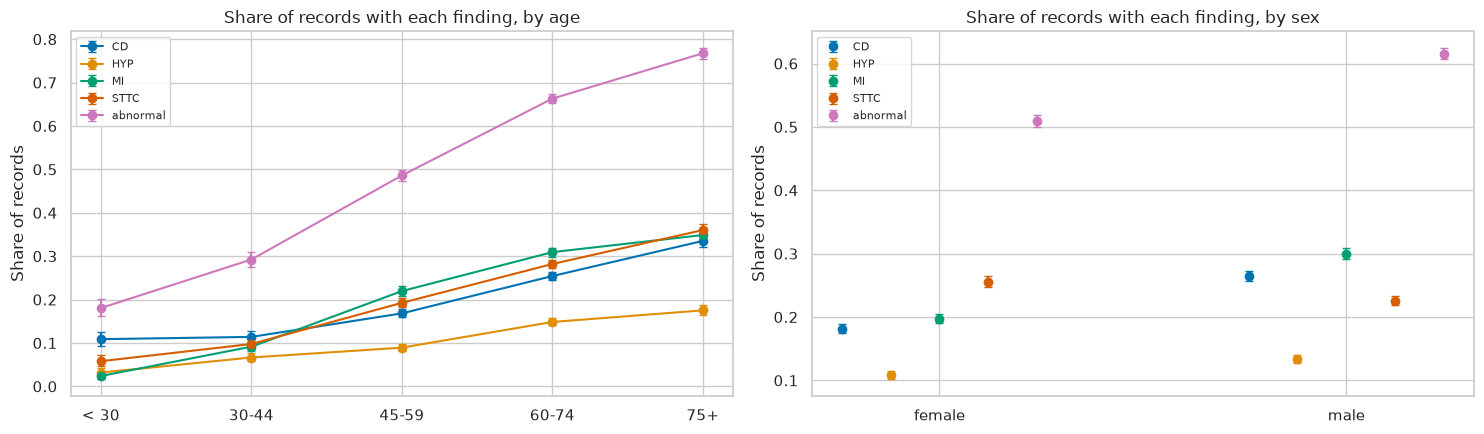

outcome,abnormal,MI,STTC,CD,HYP
age_band,,,,,
< 30,0.181,0.024,0.058,0.109,0.032
30-44,0.292,0.091,0.098,0.114,0.067
45-59,0.486,0.220,0.193,0.168,0.089
60-74,0.663,0.309,0.282,0.254,0.148
75+,0.768,0.349,0.360,0.335,0.175


Chi-square test, abnormal vs age band: p = 0.0e+00


In [9]:
outcomes = ["abnormal", "MI", "STTC", "CD", "HYP"]
by_age = prevalence(meta.dropna(subset=["age_band"]), "age_band", outcomes)
by_sex = prevalence(meta, "sex_name", outcomes)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_prevalence(by_age, "age_band", axes[0], "Share of records with each finding, by age")
plot_prevalence(by_sex, "sex_name", axes[1], "Share of records with each finding, by sex", connect=False)
plt.tight_layout()
plt.show()
display(by_age.pivot(index="age_band", columns="outcome", values="prevalence")[outcomes].round(3))
p_value = association_test(meta.dropna(subset=["age_band"]), "age_band", "abnormal")
print(f"Chi-square test, abnormal vs age band: p = {p_value:.1e}")

In [10]:
ratios = odds_ratios(meta.assign(age=meta["age_capped"]), outcomes)
display(ratios.round(3))

,outcome,predictor,odds_ratio,lower,upper,p_value
0,abnormal,age per 10 years,1.668,1.635,1.701,0.000
1,abnormal,male,1.849,1.743,1.962,0.000
2,MI,age per 10 years,1.494,1.460,1.528,0.000
3,MI,male,2.050,1.918,2.191,0.000
4,STTC,age per 10 years,1.437,1.406,1.470,0.000
5,STTC,male,0.941,0.882,1.004,0.067
6,CD,age per 10 years,1.377,1.346,1.408,0.000
7,CD,male,1.839,1.718,1.968,0.000
8,HYP,age per 10 years,1.358,1.320,1.398,0.000
9,HYP,male,1.408,1.294,1.533,0.000


In [11]:
adults = meta[meta["age_capped"] >= 18].copy()
adults["bmi"] = adults["weight"] / (adults["height"] / 100) ** 2
plausible = adults[(adults["bmi"] > 12) & (adults["bmi"] < 70)]
display(plausible.groupby("abnormal")["bmi"].describe().round(1).rename(
    index={False: "no abnormal superclass", True: "abnormal superclass"}))
repeats = meta.groupby("patient_id")["abnormal"].agg(["size", "nunique"])
repeaters = repeats[repeats["size"] > 1]
print(f"Patients with repeat ECGs whose abnormal status changes between ECGs: "
      f"{(repeaters['nunique'] > 1).sum()} of {len(repeaters)}")

,count,mean,std,min,25%,50%,75%,max
abnormal,,,,,,,,
no abnormal superclass,2960.0,25.6,4.5,13.4,22.5,25.1,28.1,58.8
abnormal superclass,3592.0,25.1,4.6,13.3,22.0,24.7,27.7,59.4


Patients with repeat ECGs whose abnormal status changes between ECGs: 417 of 2111


**Finding: age is the strongest driver, and sex matters for most findings.**

- The share of records with any abnormal superclass climbs steadily from 18% under 30 to 77% at 75 and
  over. The association is overwhelming (chi-square p effectively 0). Each additional 10 years
  multiplies the odds of an abnormal ECG by about 1.67.
- Men have about 1.85 times the odds of an abnormal ECG at the same age. The difference is largest for
  **myocardial infarction** (odds ratio about 2.0) and **conduction disturbances** (about 1.8).
  **ST/T changes are the exception**: they are not more common in men (odds ratio 0.94, p = 0.07).
  In the raw shares they are even slightly more common in women, because the women are older.
- Body mass index is essentially the same with and without an abnormal finding (median about 25).
- 417 of 2,111 patients with several ECGs change between normal and abnormal across recordings, so
  "patient" and "ECG" labels are not interchangeable.

These are associations in a hospital cohort, not risk estimates for the general population.

## 7. Signal integrity

For every one of the 21,799 records, `ecg_experiment/eda/signals.py` computes per-lead statistics from the raw 500 Hz
file (about 90 seconds on 6 cores, then cached):

- **shape and NaNs**: every record should be 5,000 x 12 with no missing samples;
- **flat leads**: a run of identical samples of at least 1 s, or a fully constant lead;
- **amplitude**: any sample above 10 mV (a normal QRS is 0.5-3 mV);
- **limb-lead identities**: the six limb leads come from three electrodes, so III = II - I,
  aVR = -(I + II)/2, aVL = (I - III)/2 and aVF = (II + III)/2 must hold. A violation above 0.05 mV means
  a lead is swapped, mislabeled, clipped or corrupted.

In [12]:
summary = ptbxl_summary(meta.drop(columns=["age_band"]))
display(problem_counts(summary).to_frame("records"))
limb = summary[["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]].max(axis=1)
problems = summary[(summary["constant_leads"] > 0) | (summary["flat_leads"] > 0) | (limb > 0.05)]
display(problems[["constant_leads", "flat_leads", "peak_abs_mv", "einthoven_residual", "device"]]
        .sort_values("peak_abs_mv", ascending=False))

,records
records,21799
any_nan,0
fully_constant_lead,1
lead_flat_for_1s,2
lead_over_10mv,47
limb_identity_violated,7
heart_rate_not_estimated,0


,constant_leads,flat_leads,peak_abs_mv,einthoven_residual,device
record_id,,,,,
10565,0,0,32.716,32.753,CS100 3
21171,0,0,16.760,0.001,CS100 3
9129,0,0,9.937,0.001,CS100 3
15867,0,0,4.240,0.767,AT-6 C
9932,0,0,4.229,0.099,AT-6 C
12722,1,3,3.611,0.001,AT-6 6
5930,0,0,2.725,0.004,AT-6 C
162,0,0,2.585,0.002,AT-6 C
19299,0,2,2.152,0.001,CS-12


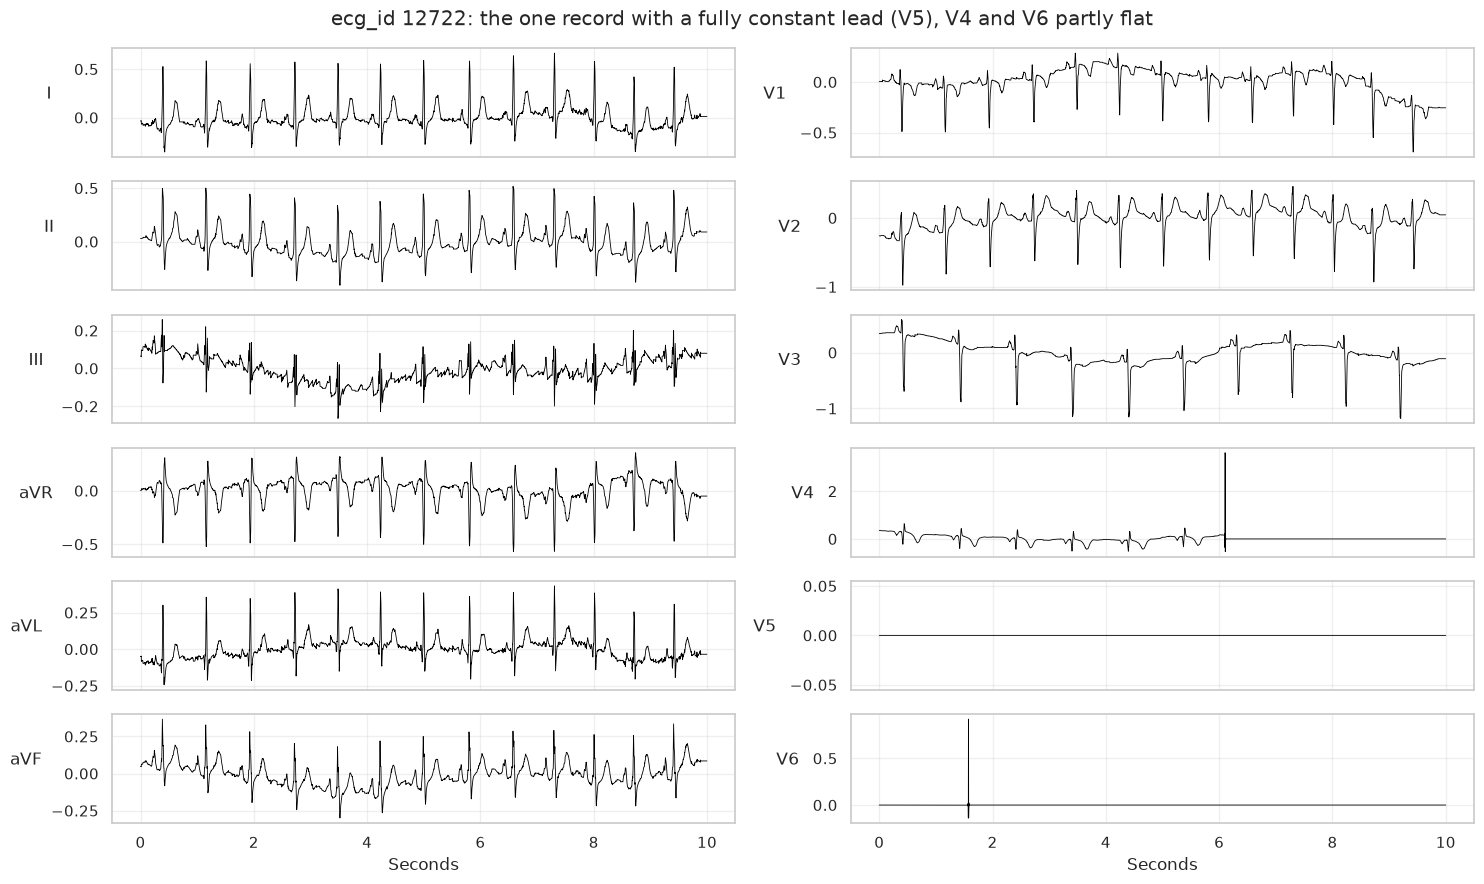

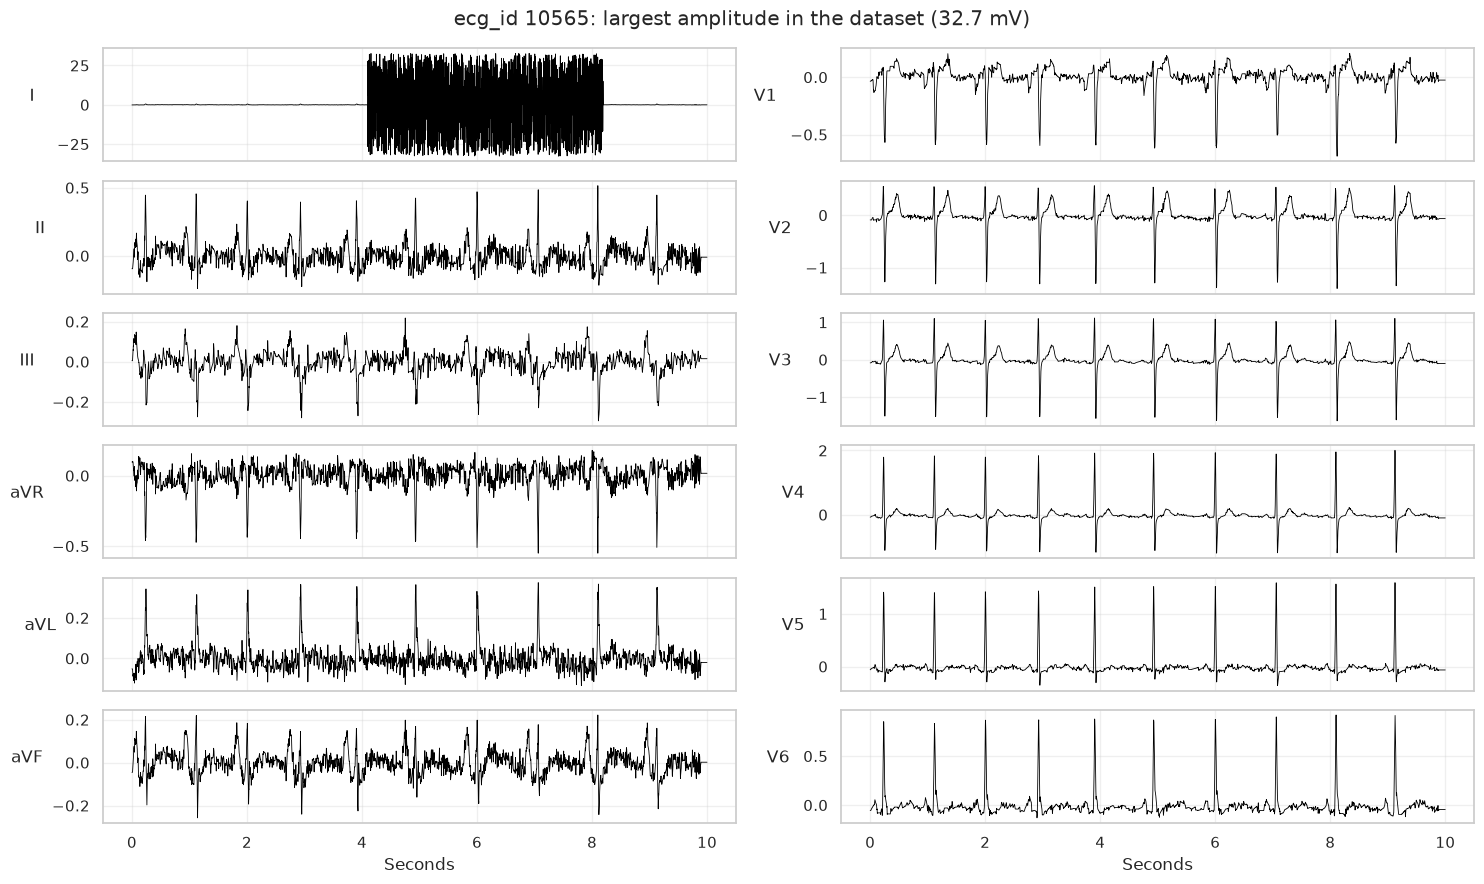

In [13]:
signal, fs = read_signal(meta.loc[12722, "filename_hr"])
plot_ecg(signal, fs, "ecg_id 12722: the one record with a fully constant lead (V5), V4 and V6 partly flat")
plt.show()
spike_id = summary["peak_abs_mv"].idxmax()
signal, fs = read_signal(meta.loc[spike_id, "filename_hr"])
peak = summary.loc[spike_id, "peak_abs_mv"]
plot_ecg(signal, fs, f"ecg_id {spike_id}: largest amplitude in the dataset ({peak:.1f} mV)")
plt.show()

**Finding: the waveforms are very clean.** Every record has exactly 5,000 samples and no NaNs. The
limb-lead identities hold to rounding (0.001 mV) in all but 7 records, so no leads are swapped
anywhere. One record (`ecg_id 12722`) has a fully constant V5, with V4 and V6 also largely flat; it
should not be used. 47 records contain short artifact spikes above 10 mV (up to 33 mV), spread across
all diagnoses; they are artifacts on otherwise usable records.

## 8. Signal distributions

Are amplitudes plausible per lead, do the noise measures mean something, do devices differ, and how
does heart rate vary with the diagnosis?

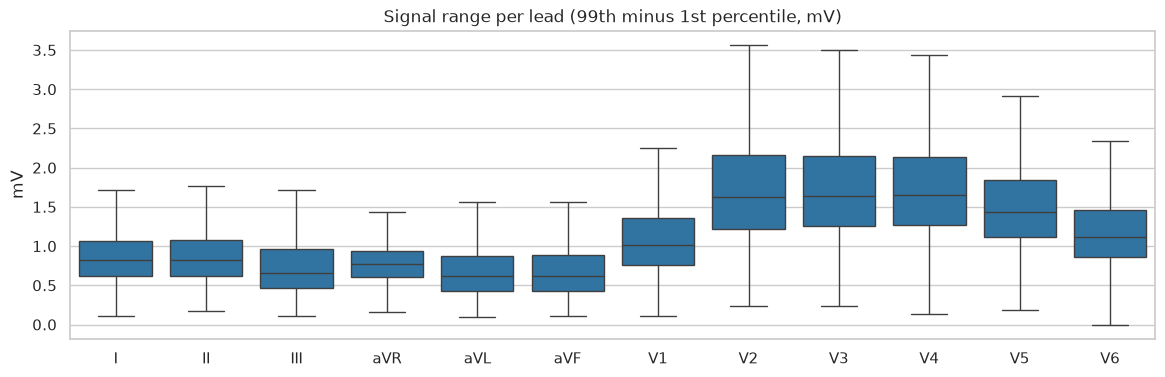

,annotation,annotated,records,baseline_fraction,high_frequency_fraction,powerline_50_fraction
0,baseline_drift,True,1598,0.065,0.006,7.000e-04
1,baseline_drift,False,20201,0.018,0.007,7.000e-04
2,static_noise,True,3260,0.011,0.009,1.000e-03
3,static_noise,False,18539,0.022,0.006,7.000e-04
4,burst_noise,True,613,0.010,0.007,7.000e-04
5,burst_noise,False,21186,0.020,0.007,7.000e-04
6,electrodes_problems,True,30,0.040,0.007,7.000e-04
7,electrodes_problems,False,21769,0.020,0.007,7.000e-04


In [14]:
leads = lead_features(meta)
leads["range_mv"] = leads["p99"] - leads["p01"]
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(leads, x="lead", y="range_mv", order=LEADS, showfliers=False, ax=ax, color="tab:blue")
ax.set(title="Signal range per lead (99th minus 1st percentile, mV)", xlabel="", ylabel="mV")
plt.show()
display(annotation_agreement(summary))

**Finding.** Amplitudes follow textbook physiology: the precordial leads V2-V5 have the largest range
(about 1.5 mV) and aVL and aVF the smallest, so the units are genuinely mV. The noise measures agree
with PTB-XL's own human annotations. Records annotated with baseline drift have 3.6x more power below
0.7 Hz (0.065 vs 0.018), and records annotated with static noise have more power above 40 Hz. We can
therefore trust these measures to compare devices here and datasets later.

,records,abnormal_share,baseline_fraction,high_frequency,signal_std
device,,,,,
AT-60 3,966,0.586,0.003,0.007,0.135
CS100 3,6140,0.681,0.003,0.006,0.146
AT-6 C,514,0.722,0.030,0.006,0.166
CS-12 E,2878,0.232,0.032,0.007,0.156
CS-12,4048,0.606,0.033,0.008,0.144
AT-6 C 5.5,3950,0.546,0.039,0.007,0.162
AT-6 C 5.0,80,0.675,0.040,0.006,0.167
AT-6 6,2273,0.577,0.042,0.007,0.163
AT-6 C 5.3,67,0.493,0.044,0.009,0.163


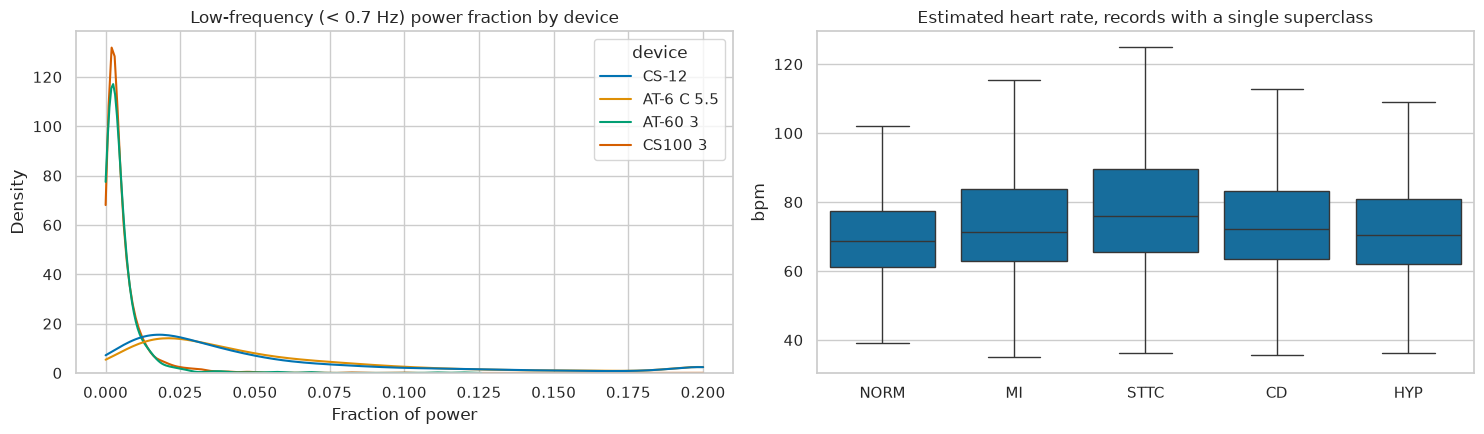

,count,mean,std,min,25%,50%,75%,max
classes,,,,,,,,
CD,1708.0,75.3,18.5,27.3,63.4,72.3,83.3,179.6
HYP,535.0,73.1,16.4,36.1,62.1,70.6,81.0,157.9
MI,2532.0,74.9,17.7,34.9,62.9,71.4,83.9,182.9
NORM,9069.0,70.3,13.2,35.8,61.2,68.6,77.5,151.5
STTC,2400.0,79.9,21.1,36.4,65.6,76.0,89.6,198.7


In [15]:
by_device = summary.groupby("device").agg(
    records=("std", "size"), abnormal_share=("abnormal", "mean"),
    baseline_fraction=("baseline_fraction", "median"), high_frequency=("high_frequency_fraction", "median"),
    signal_std=("std", "median"))
display(by_device.round(3).sort_values("baseline_fraction"))
shown = summary[summary["device"].isin(["CS100    3", "AT-60    3", "CS-12", "AT-6 C 5.5"])].copy()
shown["device"] = shown["device"].str.split().str.join(" ")
shown["baseline_fraction"] = shown["baseline_fraction"].clip(upper=0.2)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.kdeplot(shown, x="baseline_fraction", hue="device", common_norm=False, clip=(0, 0.2), ax=axes[0])
axes[0].set(title="Low-frequency (< 0.7 Hz) power fraction by device", xlabel="Fraction of power")
single = summary[summary["classes"].isin(SUPERCLASSES)]
sns.boxplot(single, x="classes", y="heart_rate", order=SUPERCLASSES, showfliers=False, ax=axes[1])
axes[1].set(title="Estimated heart rate, records with a single superclass", xlabel="", ylabel="bpm")
plt.tight_layout()
plt.show()
display(single.groupby("classes")["heart_rate"].describe().round(1))

**Finding: devices leave a fingerprint, and heart rate differs by diagnosis.**

- Two devices (`CS100 3` and `AT-60 3`) have about **10x less low-frequency power** than all the others
  (median 0.003 against 0.03-0.05). They almost certainly apply an internal high-pass filter. Devices
  also differ in their share of abnormal records (from 23% to 72%), because different wards
  used different machines. Device and diagnosis are therefore entangled in this dataset.
- NORM records have the lowest and narrowest heart-rate distribution (median about 69 bpm); STTC has the
  highest median. The heart rate is our own estimate from QRS detection; the MIMIC notebook validates it
  against machine-measured RR intervals.

## 9. Looking at the signals

One randomly chosen record from each diagnostic superclass.

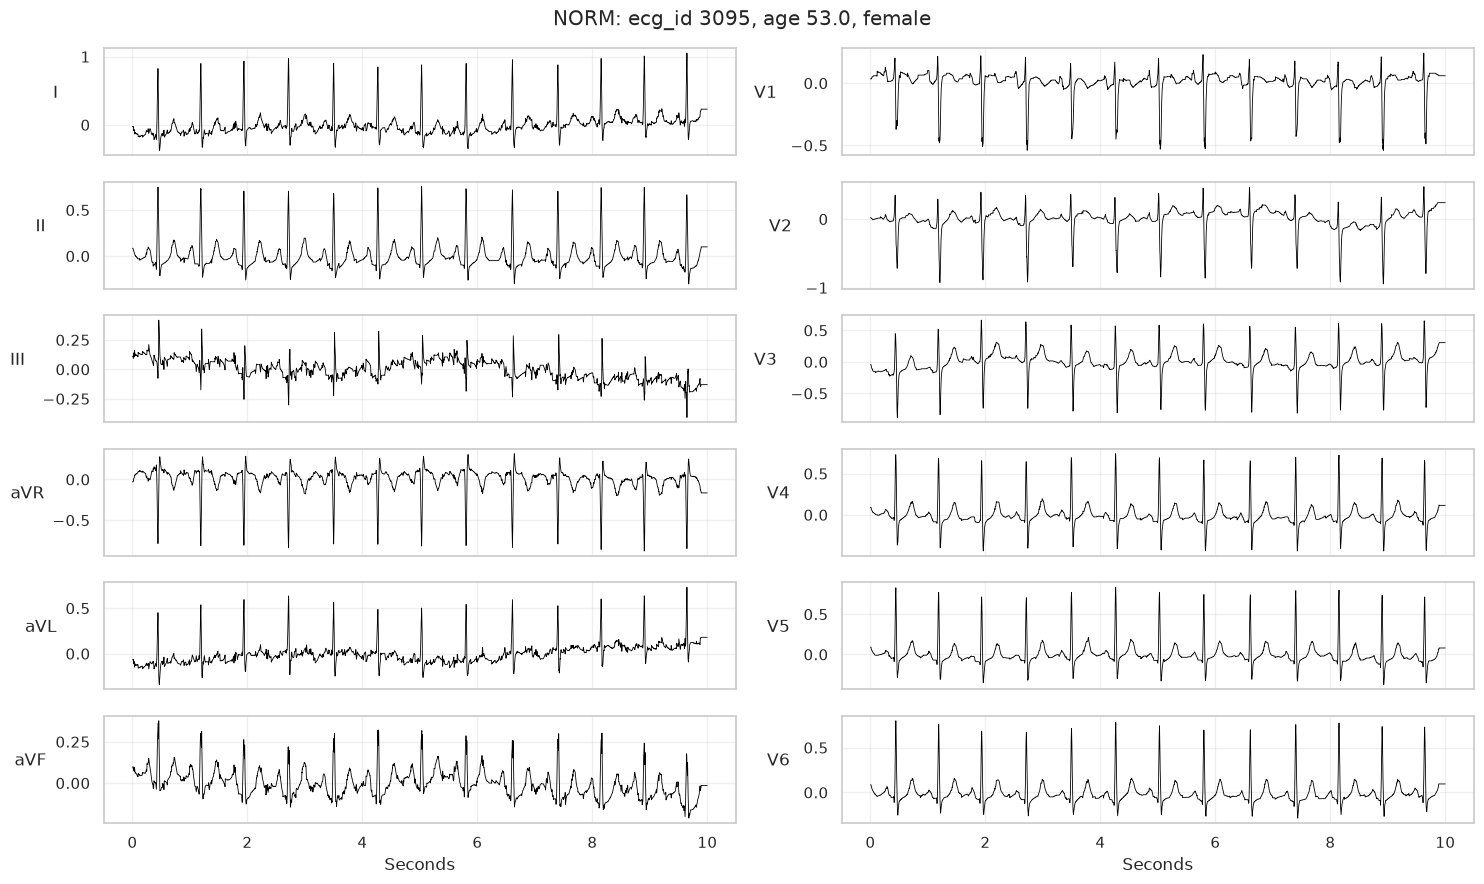

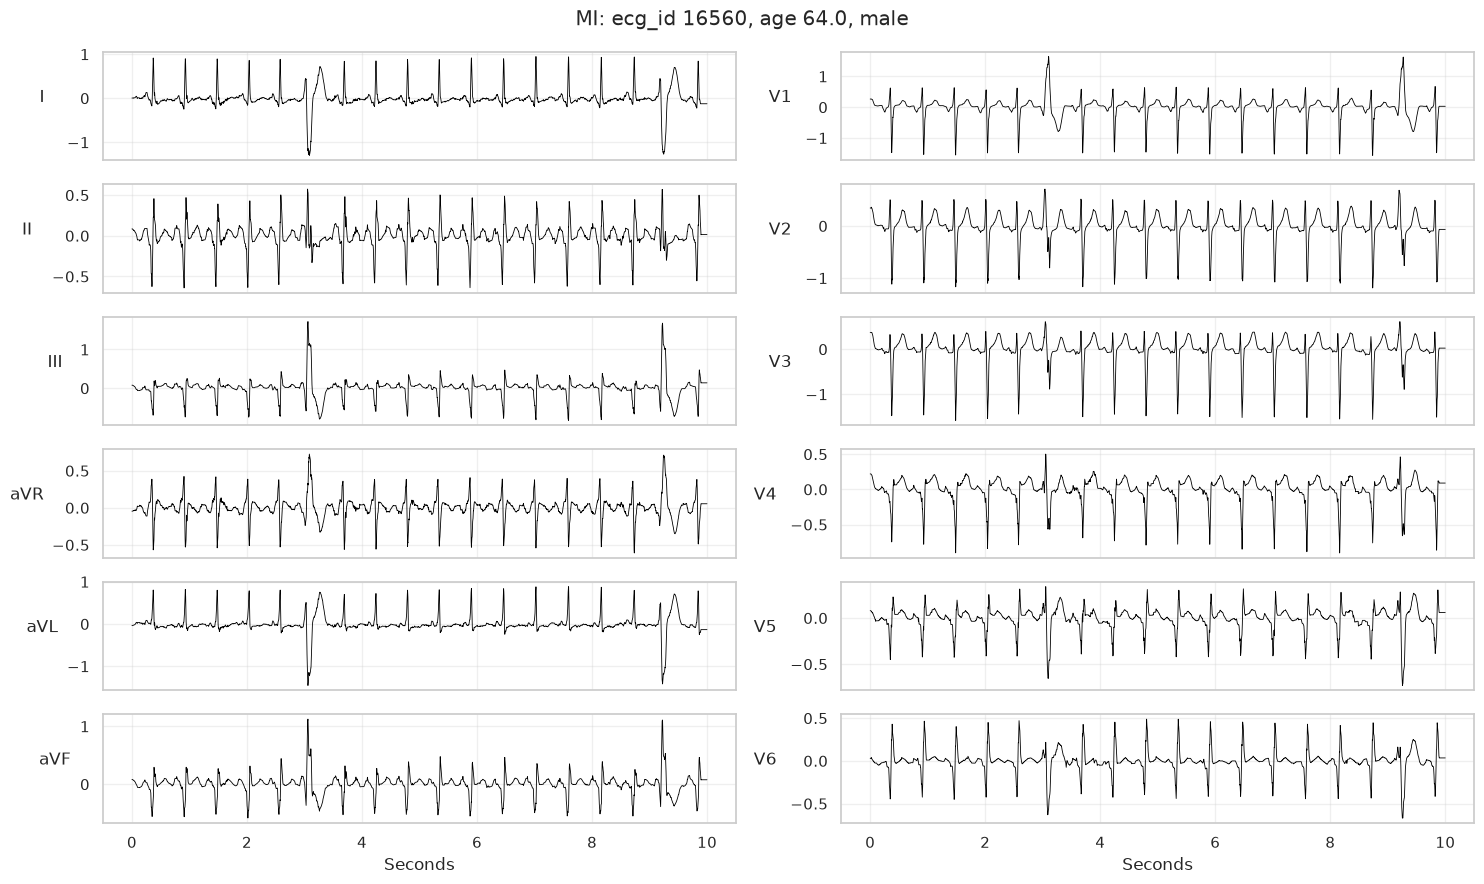

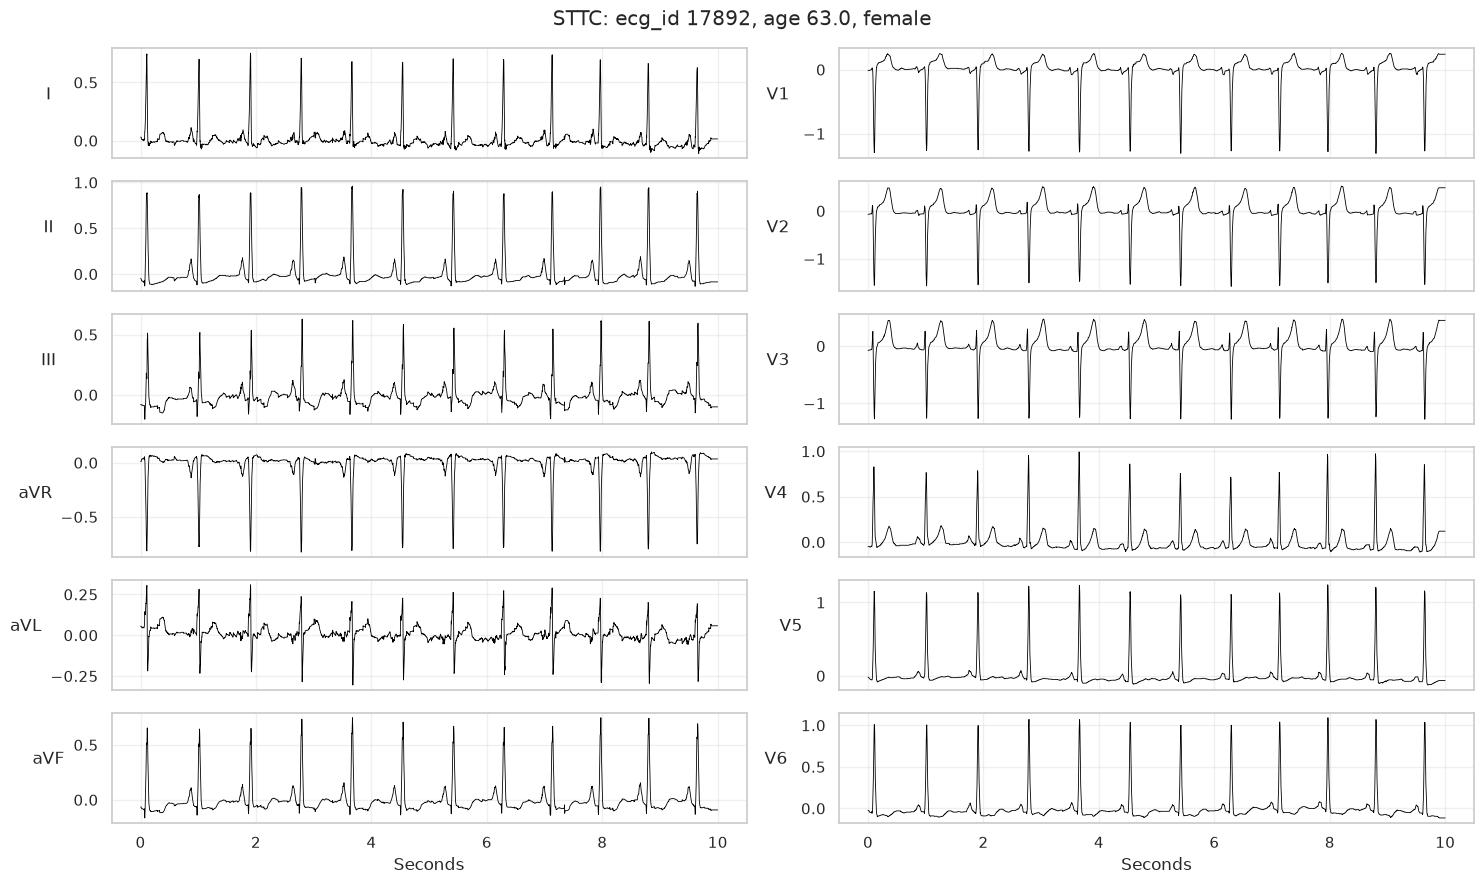

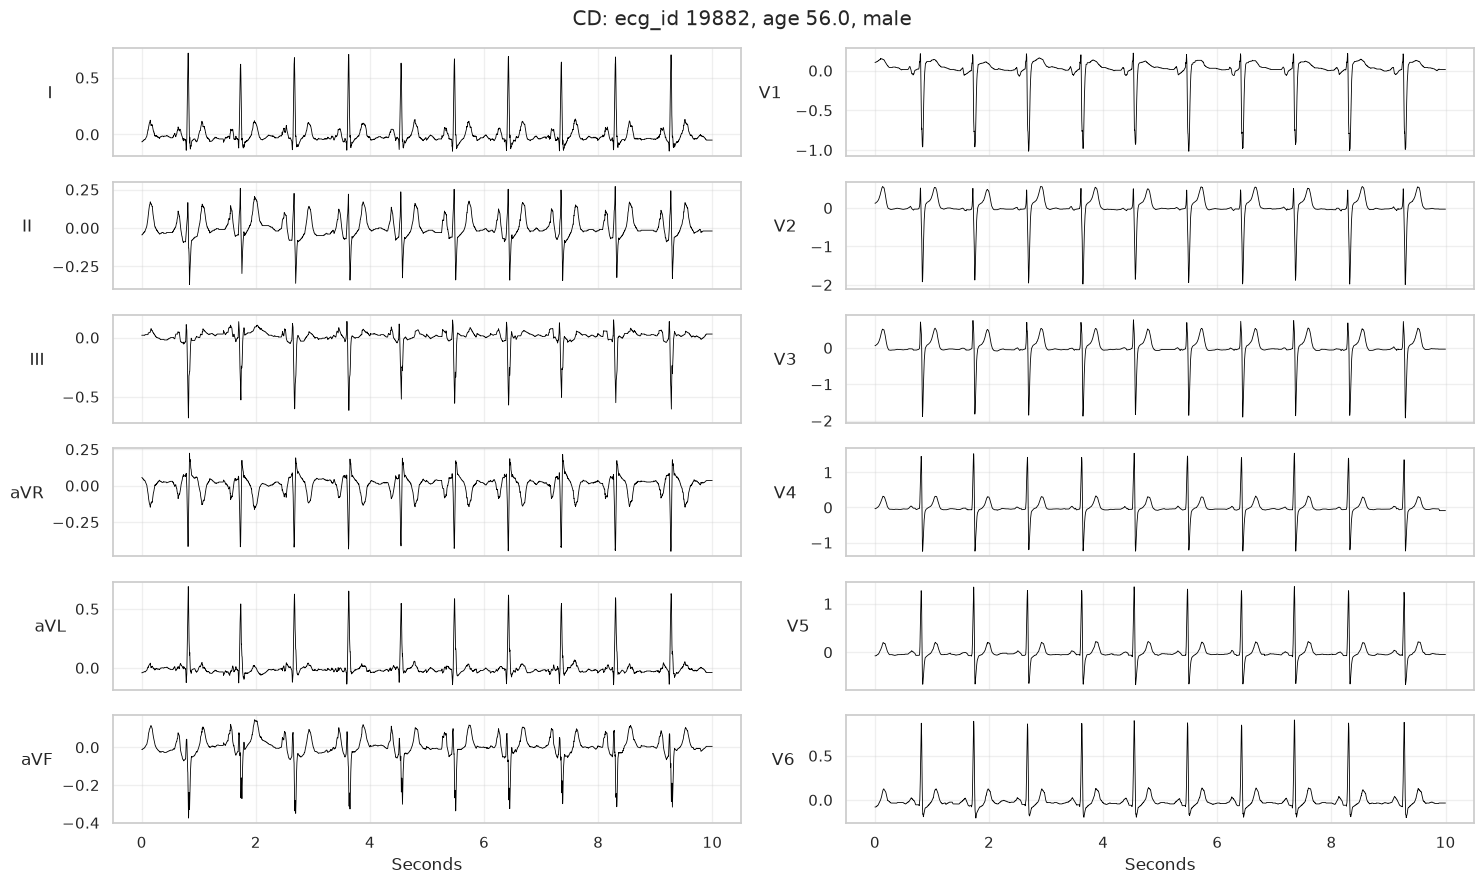

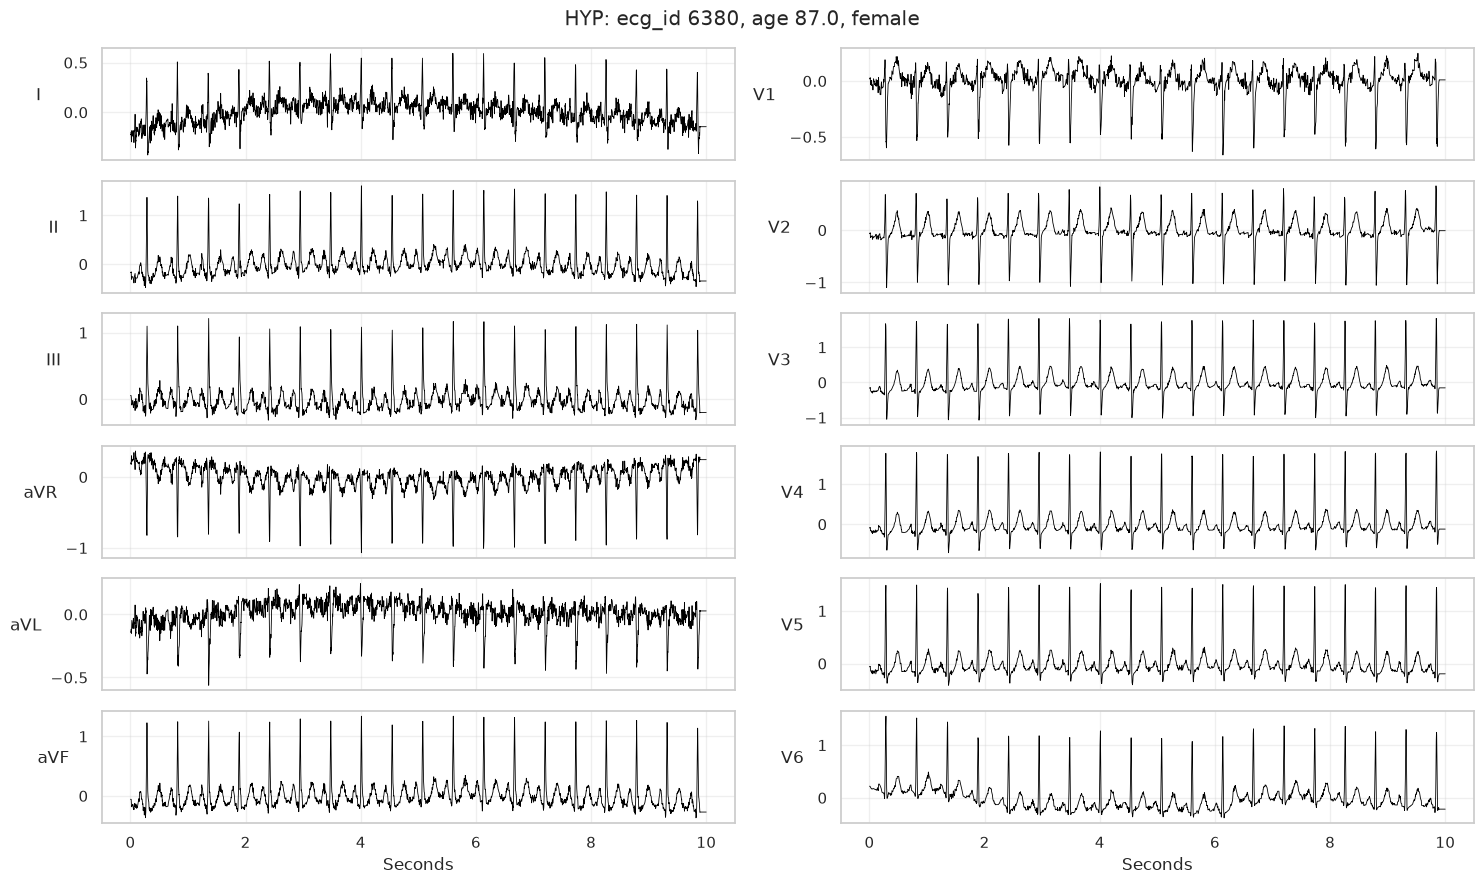

In [16]:
for group in ["NORM", "MI", "STTC", "CD", "HYP"]:
    row = meta[meta["classes"] == group].sample(1, random_state=0).iloc[0]
    signal, fs = read_signal(row["filename_hr"])
    plot_ecg(signal, fs, f"{group}: ecg_id {row.name}, age {row['age']}, {row['sex_name']}")
    plt.show()

**Finding.** The records look like standard clinical twelve-lead ECGs, with leads in the right place
(lead I and V5-V6 upright in normal sinus rhythm, aVR negative) and visible morphology changes in the
abnormal examples.

## 10. The 100 Hz version of the release

PTB-XL ships every record twice, at 500 Hz and at 100 Hz. We check that the two agree.

In [17]:
consistency = low_rate_consistency(meta, records=300)
display(consistency.describe().round(4))

,correlation,max_abs_difference_mv,median_abs_difference_mv
count,300.000,300.000,3.000e+02
mean,0.990,0.661,2.000e-03
std,0.013,0.612,1.100e-03
min,0.892,0.105,8.000e-04
25%,0.991,0.257,1.300e-03
50%,0.994,0.400,1.700e-03
75%,0.996,0.868,2.400e-03
max,1.000,3.574,5.800e-03


**Finding.** The 100 Hz files are a smoothed version of the 500 Hz files. The typical sample differs by
only about 0.002 mV (correlation 0.99), but the sharpest point of each record, usually a QRS peak,
differs by a median of 0.4 mV (up to 3.6 mV at artifact spikes). A different anti-aliasing filter was
used. The 100 Hz version blunts QRS complexes slightly, which matters for measurements of QRS amplitude
or shape.

## 11. Conclusions about the dataset

- **Structure.** 21,799 ten-second ECGs from 18,869 patients; 2,111 patients have repeat recordings, and
  417 of them change between normal and abnormal. Patient-level handling is essential.
- **Missing values.** Core fields are complete. Height and weight are mostly missing, and weight and
  heart axis are missing in a diagnosis-dependent way. Empty noise columns mean "not annotated".
- **Wrong values.** Age 300 is a placeholder for over 89 (293 records). A handful of adult heights (as
  low as 6 cm) and weights (5 kg) are data-entry errors. Children's small values are real.
- **Diagnoses.** 57% of records have an abnormal superclass. The odds rise about 1.7x per decade of age
  and are about 1.85x higher in men. Infarction and conduction disturbances are the most male-dominated;
  ST/T changes are not associated with sex once age is accounted for.
- **Signals.** Complete and clean: no NaNs, correct lead relationships, physiological amplitudes. One
  record has a dead lead, and 47 have artifact spikes.
- **Acquisition.** Devices differ in filtering and in case mix, so device is a confounder in this
  dataset. The 100 Hz release is slightly smoothed.

The next notebook describes MIMIC-IV-ECG, a much larger hospital dataset without cardiologist labels.